# Scénario de crise sanitaire

**Projet data PSL-CFX** : Hôpitaux universitaires Pitié-Salpêtrière / Charles-Foix

## Objectif

Estimer ce que deviendrait l'activité prévue si une crise sanitaire de type COVID-19
survenait. Le point central de cette étape : **les coefficients de crise ne sont pas
inventés, ils sont mesurés sur les données réelles de 2020.**

## Principe

On compare, mois par mois, ce qui s'est réellement passé en 2020 à ce qui se passait
les années normales :

$$\text{coefficient}(m) = \frac{\text{passages de 2020 au mois } m}{\text{moyenne 2017-2019 du mois } m}$$

Un coefficient de 0,54 en avril signifie qu'il n'y a eu, ce mois-là, que **54 % des
passages d'un mois d'avril ordinaire**. Ces douze coefficients sont ensuite appliqués à
la prévision « en mode normal » produite à l'étape précédente.

## Déroulé

1. Mesure des douze coefficients sur les données DREES
2. Contexte documentaire : deux sources publiques qui expliquent le phénomène
3. Application à la prévision SARIMA
4. Comparaison graphique des deux trajectoires
5. Hypothèses et limites

## 1. Mesure des coefficients de crise

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

%matplotlib inline


def trouver_racine(depart: Path) -> Path:
    """Remonte l'arborescence jusqu'au dossier contenant requirements.txt."""
    for dossier in [depart, *depart.parents]:
        if (dossier / "requirements.txt").exists():
            return dossier
    raise RuntimeError("Racine du projet introuvable")


RACINE = trouver_racine(Path.cwd())
FICHIER_DREES = RACINE / "data" / "external" / "passages_urgences_drees_2017_2023.csv"
DOSSIER_TRAITE = RACINE / "data" / "processed"

DEPARTEMENT = "75"                     # Paris, où se trouve la Pitié-Salpêtrière
ANNEES_REFERENCE = [2017, 2018, 2019]  # années normales, avant l'épidémie
ANNEE_CRISE = 2020

MOIS_COURTS = ["Janv.", "Févr.", "Mars", "Avr.", "Mai", "Juin",
               "Juil.", "Août", "Sept.", "Oct.", "Nov.", "Déc."]
MOIS_LONGS = ["janvier", "février", "mars", "avril", "mai", "juin",
              "juillet", "août", "septembre", "octobre", "novembre", "décembre"]

formateur_milliers = FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", "\u202f"))
BLEU, ROUGE, VERT, GRIS = "#1f77b4", "#d62728", "#2ca02c", "#777777"

print("Fichier DREES :", FICHIER_DREES.relative_to(RACINE))

Fichier DREES : data\external\passages_urgences_drees_2017_2023.csv


In [2]:
# Le fichier est livré au format ISO avec le séparateur point-virgule.
urgences = pd.read_csv(FICHIER_DREES, sep=";", dtype={"dep": str})
urgences["date"] = pd.to_datetime(urgences["date"], format="%Y-%m-%d")
urgences["annee"] = urgences["date"].dt.year
urgences["mois"] = urgences["date"].dt.month

paris = urgences[urgences["dep"] == DEPARTEMENT]

# Contrôle de complétude : les années utilisées doivent être entières.
for annee in [*ANNEES_REFERENCE, ANNEE_CRISE]:
    jours = paris.loc[paris["annee"] == annee, "date"].nunique()
    attendus = 366 if annee % 4 == 0 else 365
    print(f"{annee} : {jours} jours sur {attendus} attendus")
    assert jours == attendus, f"Année {annee} incomplète"

print(f"\nDépartement {DEPARTEMENT} ({paris['libelle_dep'].iloc[0]})")

2017 : 365 jours sur 365 attendus
2018 : 365 jours sur 365 attendus
2019 : 365 jours sur 365 attendus
2020 : 366 jours sur 366 attendus

Département 75 (Paris)


In [3]:
# --- Référence « normale » : moyenne des trois années pré-COVID, mois par mois ---
# On somme d'abord par (année, mois), puis on moyenne sur les années : ainsi chaque
# année pèse autant, et le résultat n'est pas tiré par l'année la plus fréquentée.
reference = (
    paris[paris["annee"].isin(ANNEES_REFERENCE)]
    .groupby(["annee", "mois"])["nb_passages"].sum()
    .groupby("mois").mean()
)

# --- Année de crise ---
crise_2020 = (
    paris[paris["annee"] == ANNEE_CRISE]
    .groupby("mois")["nb_passages"].sum()
)

# --- Coefficient de crise ---
coefficients = (crise_2020 / reference).rename("COEFFICIENT")

tableau = pd.DataFrame({
    "Mois": [MOIS_LONGS[m - 1] for m in coefficients.index],
    f"Moyenne {ANNEES_REFERENCE[0]}-{ANNEES_REFERENCE[-1]}": reference.round(0),
    f"Réel {ANNEE_CRISE}": crise_2020.round(0),
    "Coefficient": coefficients.round(4),
    "Écart": (coefficients - 1).map(lambda v: f"{v:+.1%}"),
})
tableau.index.name = "MOIS"
display(tableau)

print(f"Coefficient minimal : {coefficients.min():.3f} "
      f"en {MOIS_LONGS[coefficients.idxmin() - 1]}")
print(f"Coefficient maximal : {coefficients.max():.3f} "
      f"en {MOIS_LONGS[coefficients.idxmax() - 1]}")
print(f"Sur l'année entière : {crise_2020.sum() / reference.sum():.3f} "
      f"({crise_2020.sum() / reference.sum() - 1:+.1%} de passages)")

,Mois,Moyenne 2017-2019,Réel 2020,Coefficient,Écart
MOIS,,,,,
1,janvier,79946.0,83979.0,1.0505,+5.0%
2,février,70790.0,78640.0,1.1109,+11.1%
3,mars,78925.0,62984.0,0.7980,-20.2%
4,avril,75197.0,40848.0,0.5432,-45.7%
5,mai,78295.0,49779.0,0.6358,-36.4%
6,juin,78024.0,59530.0,0.7630,-23.7%
7,juillet,75012.0,63239.0,0.8431,-15.7%
8,août,66397.0,60827.0,0.9161,-8.4%
9,septembre,75086.0,71541.0,0.9528,-4.7%


Coefficient minimal : 0.543 en avril
Coefficient maximal : 1.111 en février
Sur l'année entière : 0.804 (-19.6% de passages)


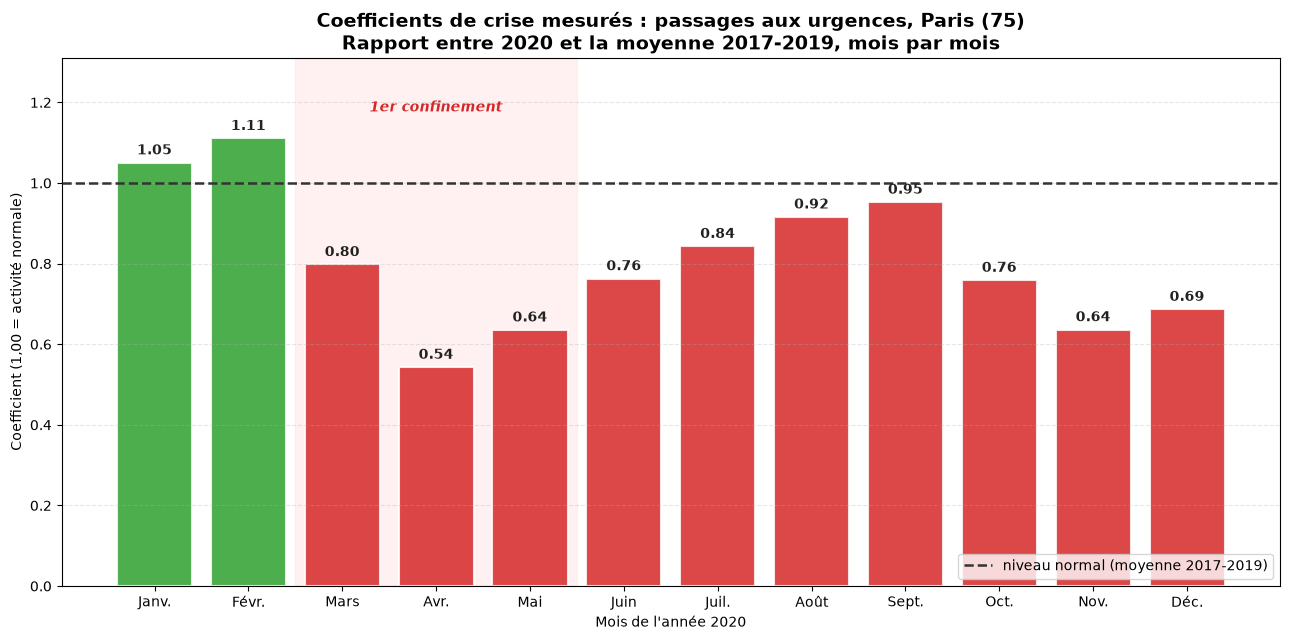

In [4]:
fig, ax = plt.subplots(figsize=(13, 6.5))

# Rouge en dessous de la normale, vert au-dessus : lecture immédiate
couleurs = [ROUGE if v < 1 else VERT for v in coefficients.values]
barres = ax.bar(coefficients.index, coefficients.values, color=couleurs,
                alpha=0.85, edgecolor="white", linewidth=1.5)

ax.axhline(1.0, color="#333333", linestyle="--", linewidth=1.8,
           label="niveau normal (moyenne 2017-2019)", zorder=3)

# Valeur inscrite sur chaque barre
for mois, valeur in zip(coefficients.index, coefficients.values):
    ax.annotate(f"{valeur:.2f}", xy=(mois, valeur), xytext=(0, 6),
                textcoords="offset points", ha="center",
                fontsize=10, fontweight="bold", color="#222222")

# Repérage de la période du premier confinement (17 mars - 11 mai 2020)
ax.axvspan(2.5, 5.5, color="#ffe0e0", alpha=0.45, zorder=0)
ax.text(4, coefficients.max() * 1.06, "1er confinement",
        ha="center", fontsize=10, style="italic", color=ROUGE, fontweight="bold")

ax.set_title(
    f"Coefficients de crise mesurés : passages aux urgences, Paris ({DEPARTEMENT})\n"
    f"Rapport entre {ANNEE_CRISE} et la moyenne "
    f"{ANNEES_REFERENCE[0]}-{ANNEES_REFERENCE[-1]}, mois par mois",
    fontsize=13.5, fontweight="bold",
)
ax.set_xlabel("Mois de l'année 2020")
ax.set_ylabel("Coefficient (1,00 = activité normale)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MOIS_COURTS)
ax.set_ylim(0, coefficients.max() * 1.18)
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

### Lecture des coefficients

Trois choses ressortent, toutes conformes à ce que l'on sait de 2020 :

**Janvier et février sont au-dessus de la normale** (1,05 et 1,11). Ce ne sont pas des
mois de crise : le premier confinement débute le 17 mars 2020. Ce surcroît d'activité
correspond à une saison grippale soutenue. C'est une bonne nouvelle méthodologique :
**les coefficients détectent d'eux-mêmes le début de la crise**, sans qu'on ait eu à le
leur indiquer.

**L'effondrement du printemps est brutal.** Avril tombe à **0,54**, quasiment un
passage sur deux en moins. Mars (0,80) n'est qu'à demi touché puisque le confinement
ne commence qu'à la mi-mois.

**La reprise est réelle mais interrompue.** De mai à septembre, le coefficient remonte
régulièrement jusqu'à 0,95, puis redescend à 0,64 en novembre : c'est le deuxième
confinement, du 30 octobre au 15 décembre 2020.

Sur l'année entière, Paris enregistre **19,7 % de passages en moins** qu'une
année normale : 742 410 passages en 2020, contre 923 956 en moyenne sur
2017-2019. La baisse annuelle est bien moindre que le creux d'avril, parce que
les mois de janvier et février, antérieurs à la crise, la compensent en partie.

In [5]:
chemin_coefficients = DOSSIER_TRAITE / "coefficients_crise.csv"

# En-tête de commentaires : le fichier doit rester interprétable seul, sans le notebook.
entete = f"""# Coefficients de crise sanitaire mesures sur les donnees reelles du COVID-19
# ---------------------------------------------------------------------------
# Methode  : coefficient(mois) = passages {ANNEE_CRISE}(mois) / moyenne {ANNEES_REFERENCE[0]}-{ANNEES_REFERENCE[-1]}(mois)
#            La moyenne de reference est calculee annee par annee puis moyennee,
#            afin que chaque annee de reference pese identiquement.
# Lecture  : 1,00 = activite normale ; 0,54 = 54 % d'une activite normale
# Perimetre: departement {DEPARTEMENT} (Paris), passages aux urgences toutes causes
# Source   : DREES, "Series longues corrigees du nombre de passages aux urgences
#            2017 a 2023 en France", data.gouv.fr, Licence Ouverte 2.0
# Fichier  : data/external/passages_urgences_drees_2017_2023.csv
# Import   : pd.read_csv("coefficients_crise.csv", comment="#")
# ---------------------------------------------------------------------------
"""

sortie_coefficients = coefficients.round(4).reset_index()
sortie_coefficients.columns = ["MOIS", "COEFFICIENT"]

with chemin_coefficients.open("w", encoding="utf-8", newline="") as fichier:
    fichier.write(entete)
    sortie_coefficients.to_csv(fichier, index=False)

# Relecture de contrôle : le fichier doit être exploitable tel quel
verification = pd.read_csv(chemin_coefficients, comment="#")
assert len(verification) == 12, "Le fichier doit contenir 12 mois"
assert np.allclose(verification["COEFFICIENT"], coefficients.values, atol=1e-4)

print(f"Écrit : {chemin_coefficients.relative_to(RACINE)}")
print(f"Relecture avec comment='#' : {len(verification)} lignes, contrôle OK")
verification

Écrit : data\processed\coefficients_crise.csv
Relecture avec comment='#' : 12 lignes, contrôle OK


,MOIS,COEFFICIENT
0,1,1.0505
1,2,1.1109
2,3,0.7980
3,4,0.5432
4,5,0.6358
5,6,0.7630
6,7,0.8431
7,8,0.9161
8,9,0.9528
9,10,0.7590


## 2. Contexte documentaire

Les deux publications ci-dessous **expliquent et confirment** le phénomène mesuré plus
haut. Elles ne se substituent pas au calcul : les coefficients utilisés dans ce notebook
proviennent exclusivement des données DREES, pas de ces textes.

### Source 1 : DREES

**Hamid Khaoua** (avec la collaboration de Milena Suarez Castillo), *Passages aux
urgences entre 2017 et 2023 : des dynamiques contrastées selon les départements*,
**Études et Résultats n° 1320**, DREES, 12 décembre 2024.

<https://drees.solidarites-sante.gouv.fr/publications-communique-de-presse/etudes-et-resultats/241212_ER_passages-aux-urgences>

C'est l'étude qui accompagne le jeu de données utilisé ici. Elle établit que le nombre
de passages aux urgences en France **chute à 18,1 millions en 2020**, contre 22 millions
en 2019, une rupture nette après deux décennies de croissance continue (10,1 millions
en 1996). Elle situe les baisses les plus marquées lors des **confinements de mars et de
novembre 2020**, avec une remontée progressive à partir de mai 2021. Nos coefficients
mensuels, calculés sur le seul département 75, retrouvent exactement ce calendrier.

### Source 2 : Santé publique France

*Covid-19 et continuité des soins - Continuer de se soigner, un impératif de santé
publique*, communiqué de presse, Santé publique France, 7 mai 2020.

<https://www.santepubliquefrance.fr/presse/2020/covid-19-et-continuite-des-soins-continuer-de-se-soigner-un-imperatif-de-sante-publique>

Ce communiqué documente les **causes** de la baisse, ce que les chiffres seuls ne disent
pas. Il constate un recul des passages aux urgences et des hospitalisations pour
pathologies cardio- et neuro-vasculaires dès les semaines 12-13 de 2020, puis une
**remontée en semaine 17** qu'il interprète comme un retard de prise en charge : des
patients ont attendu avant de se rendre aux urgences, **par crainte de la
contamination**. Il relève également une chute des consultations de **25 % chez les
généralistes et de 51 % chez les spécialistes** à la mi-avril 2020.

**Ce qu'il faut en retenir pour la modélisation.** La baisse des passages ne traduit pas
une amélioration de l'état de santé de la population : elle mêle un effet réel (moins
d'accidents de la route, moins de viroses grâce aux gestes barrières) et un **renoncement
aux soins** aux conséquences sanitaires propres. Un coefficient de 0,54 ne signifie donc
pas que l'hôpital a besoin de deux fois moins de moyens : une partie de cette activité
est simplement différée.

## 3. Application à la prévision

On reprend la prévision « mode normal » de l'étape précédente et on simule une crise qui
**démarrerait au 3ᵉ mois de l'horizon**.

Les coefficients sont appliqués dans l'ordre chronologique de la crise réelle : le
premier mois de crise reçoit le coefficient de **mars 2020**, le deuxième celui d'**avril
2020**, et ainsi de suite. Les deux premiers mois de l'horizon restent en mode normal
(coefficient 1,00).

In [6]:
prevision = pd.read_csv(DOSSIER_TRAITE / "prevision_12mois.csv", parse_dates=["DATE"])
prevision = prevision.sort_values("DATE").reset_index(drop=True)

print(f"Prévision chargée : {len(prevision)} mois, "
      f"de {prevision['DATE'].min():%m/%Y} à {prevision['DATE'].max():%m/%Y}")

# Le scénario démarre au 3e mois de l'horizon (indice 2, la numérotation commençant à 0)
RANG_DEBUT_CRISE = 3
MOIS_PREMIER_COEFFICIENT = 3  # mars 2020 = premier mois réellement touché

scenario = prevision[["DATE", "PREVISION"]].rename(columns={"PREVISION": "PREVISION_NORMAL"})
scenario["RANG"] = range(1, len(scenario) + 1)

# EN_CRISE marque les mois situés à partir du déclenchement ; avant, activité normale.
scenario["DEBUT_CRISE"] = scenario["RANG"] >= RANG_DEBUT_CRISE


def coefficient_du_rang(rang: int) -> float:
    """Coefficient à appliquer au mois de rang donné dans l'horizon de prévision.

    Hors crise : 1,00. En crise : on avance dans le calendrier réel de 2020 à partir
    de mars, mois de crise après mois de crise.
    """
    if rang < RANG_DEBUT_CRISE:
        return 1.0
    rang_dans_la_crise = rang - RANG_DEBUT_CRISE           # 0 pour le premier mois touché
    mois_2020 = MOIS_PREMIER_COEFFICIENT + rang_dans_la_crise
    if mois_2020 > 12:
        raise ValueError(
            f"L'horizon dépasse décembre 2020 : {mois_2020 - 12} mois sans coefficient mesuré."
        )
    return float(coefficients[mois_2020])


scenario["MOIS_2020_APPLIQUE"] = scenario["RANG"].map(
    lambda r: MOIS_LONGS[MOIS_PREMIER_COEFFICIENT + r - RANG_DEBUT_CRISE - 1]
    if r >= RANG_DEBUT_CRISE else "—"
)
scenario["COEFFICIENT"] = scenario["RANG"].map(coefficient_du_rang)
scenario["PREVISION_CRISE"] = scenario["PREVISION_NORMAL"] * scenario["COEFFICIENT"]

affichage = scenario.copy()
affichage["DATE"] = affichage["DATE"].dt.strftime("%m/%Y")
display(affichage[["DATE", "RANG", "DEBUT_CRISE", "MOIS_2020_APPLIQUE",
                   "COEFFICIENT", "PREVISION_NORMAL", "PREVISION_CRISE"]].round(2))

Prévision chargée : 12 mois, de 01/2016 à 12/2016


,DATE,RANG,DEBUT_CRISE,MOIS_2020_APPLIQUE,COEFFICIENT,PREVISION_NORMAL,PREVISION_CRISE
0,01/2016,1,False,—,1.00,4322.03,4322.03
1,02/2016,2,False,—,1.00,3771.63,3771.63
2,03/2016,3,True,mars,0.80,4261.12,3400.47
3,04/2016,4,True,avril,0.54,4036.12,2192.49
4,05/2016,5,True,mai,0.64,4223.76,2685.43
5,06/2016,6,True,juin,0.76,4207.76,3210.40
6,07/2016,7,True,juillet,0.84,4025.34,3393.58
7,08/2016,8,True,août,0.92,3507.96,3213.68
8,09/2016,9,True,septembre,0.95,4030.02,3839.78
9,10/2016,10,True,octobre,0.76,4503.05,3417.68


In [7]:
total_normal = scenario["PREVISION_NORMAL"].sum()
total_crise = scenario["PREVISION_CRISE"].sum()
perte = total_normal - total_crise

mois_creux = scenario.loc[scenario["PREVISION_CRISE"].idxmin()]
baisse_max = 1 - mois_creux["COEFFICIENT"]

print(f"Total sur 12 mois en mode normal : {total_normal:,.0f} passages".replace(",", "\u202f"))
print(f"Total sur 12 mois avec crise     : {total_crise:,.0f} passages".replace(",", "\u202f"))
print(f"Différence                       : {perte:,.0f} passages "
      f"({total_crise / total_normal - 1:+.1%})".replace(",", "\u202f"))
print()
print(f"Mois le plus touché : {mois_creux['DATE']:%m/%Y} "
      f"(coefficient {mois_creux['COEFFICIENT']:.2f}, soit {baisse_max:.0%} de baisse)")
print(f"  {mois_creux['PREVISION_NORMAL']:,.0f} passages attendus -> "
      f"{mois_creux['PREVISION_CRISE']:,.0f} sous scénario de crise".replace(",", "\u202f"))

Total sur 12 mois en mode normal : 49 744 passages
Total sur 12 mois avec crise     : 39 307 passages
Différence                       : 10 437 passages (-21.0%)

Mois le plus touché : 04/2016 (coefficient 0.54, soit 46% de baisse)
  4 036 passages attendus -> 2 192 sous scénario de crise


In [8]:
chemin_scenario = DOSSIER_TRAITE / "prevision_crise.csv"

sortie = scenario[["DATE", "PREVISION_NORMAL", "PREVISION_CRISE", "DEBUT_CRISE"]].copy()
sortie["DATE"] = sortie["DATE"].dt.strftime("%Y-%m-%d")
sortie["PREVISION_NORMAL"] = sortie["PREVISION_NORMAL"].round(2)
sortie["PREVISION_CRISE"] = sortie["PREVISION_CRISE"].round(2)
sortie.to_csv(chemin_scenario, index=False, encoding="utf-8")

# Contrôles : cohérence entre les deux trajectoires
assert len(sortie) == len(prevision), "Le scénario doit couvrir tout l'horizon"
avant = scenario[~scenario["DEBUT_CRISE"]]
assert np.allclose(avant["PREVISION_NORMAL"], avant["PREVISION_CRISE"]), \
    "Les mois hors crise doivent rester identiques à la prévision normale"

print(f"Écrit : {chemin_scenario.relative_to(RACINE)} ({len(sortie)} lignes)")
print(f"Colonnes : {', '.join(sortie.columns)}")
print(f"\nMois hors crise : {(~scenario['DEBUT_CRISE']).sum()} "
      f"| Mois en crise : {scenario['DEBUT_CRISE'].sum()}")
sortie.head(4)

Écrit : data\processed\prevision_crise.csv (12 lignes)
Colonnes : DATE, PREVISION_NORMAL, PREVISION_CRISE, DEBUT_CRISE

Mois hors crise : 2 | Mois en crise : 10


,DATE,PREVISION_NORMAL,PREVISION_CRISE,DEBUT_CRISE
0,2016-01-01,4322.03,4322.03,False
1,2016-02-01,3771.63,3771.63,False
2,2016-03-01,4261.12,3400.47,True
3,2016-04-01,4036.12,2192.49,True


## 4. Comparaison des deux trajectoires

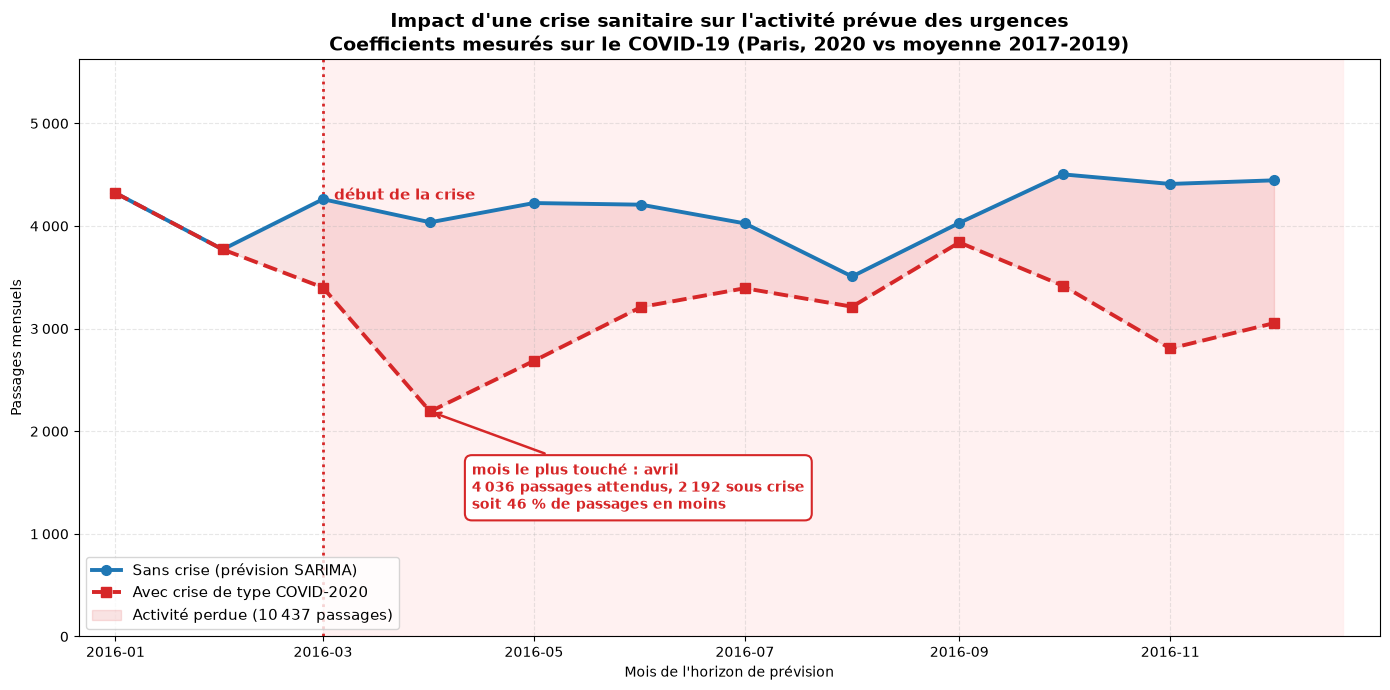

Sur douze mois  le scénario retire 10 437 passages (21.0% de l'activité prévue).


In [9]:
fig, ax = plt.subplots(figsize=(14, 7))

dates = scenario["DATE"]
debut_crise = scenario.loc[scenario["DEBUT_CRISE"], "DATE"].min()

# Zone ombrée sur toute la période de crise
ax.axvspan(debut_crise, dates.max() + pd.DateOffset(days=20),
           color="#ffecec", alpha=0.7, zorder=0)

ax.plot(dates, scenario["PREVISION_NORMAL"], color=BLEU, linewidth=2.8,
        marker="o", markersize=7, label="Sans crise (prévision SARIMA)", zorder=3)
ax.plot(dates, scenario["PREVISION_CRISE"], color=ROUGE, linewidth=2.8,
        marker="s", markersize=7, linestyle="--",
        label="Avec crise de type COVID-2020", zorder=3)

# L'écart entre les deux courbes, matérialisé
ax.fill_between(dates, scenario["PREVISION_CRISE"], scenario["PREVISION_NORMAL"],
                color=ROUGE, alpha=0.13, zorder=1,
                label=f"Activité perdue ({perte:,.0f} passages)".replace(",", "\u202f"))

# Repère du déclenchement
ax.axvline(debut_crise, color=ROUGE, linestyle=":", linewidth=2, zorder=2)
ax.annotate("début de la crise",
            xy=(debut_crise, ax.get_ylim()[1]), xytext=(8, -18),
            textcoords="offset points", fontsize=10.5, fontweight="bold",
            color=ROUGE, va="top")

# Le mois le plus touché, expliqué en clair.
# Les nombres sont mis en forme séparément : appliquer .replace() à la phrase
# entière transformerait aussi les virgules de ponctuation en séparateurs.
date_creux = mois_creux["DATE"]
attendus = f"{mois_creux['PREVISION_NORMAL']:,.0f}".replace(",", "\u202f")
sous_crise = f"{mois_creux['PREVISION_CRISE']:,.0f}".replace(",", "\u202f")
ax.annotate(
    f"mois le plus touché : {MOIS_LONGS[date_creux.month - 1]}\n"
    f"{attendus} passages attendus, {sous_crise} sous crise\n"
    f"soit {baisse_max * 100:.0f} % de passages en moins",
    xy=(date_creux, mois_creux["PREVISION_CRISE"]),
    xytext=(30, -70), textcoords="offset points",
    fontsize=10, fontweight="bold", color=ROUGE, ha="left",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor=ROUGE, linewidth=1.5),
    arrowprops=dict(arrowstyle="->", color=ROUGE, linewidth=1.8),
)

ax.set_title(
    "Impact d'une crise sanitaire sur l'activité prévue des urgences\n"
    "Coefficients mesurés sur le COVID-19 (Paris, 2020 vs moyenne 2017-2019)",
    fontsize=14, fontweight="bold",
)
ax.set_xlabel("Mois de l'horizon de prévision")
ax.set_ylabel("Passages mensuels")
ax.yaxis.set_major_formatter(formateur_milliers)
ax.legend(fontsize=10.5, loc="lower left")
ax.grid(alpha=0.3, linestyle="--")
ax.margins(x=0.03)
ax.set_ylim(0, scenario["PREVISION_NORMAL"].max() * 1.25)

plt.tight_layout()
plt.show()

print(f"Sur douze mois, le scénario retire {perte:,.0f} passages "
      f"({1 - total_crise / total_normal:.1%} de l'activité prévue).".replace(",", "\u202f"))

## 5. Hypothèses et limites

**Les coefficients décrivent le COVID-2020, pas « une crise » en général.** Ils portent
la signature d'une épidémie respiratoire accompagnée de confinements : une chute massive
des passages, par renoncement aux soins et par disparition d'une partie des motifs
habituels. **Une autre crise produirait un profil différent, et parfois de signe
opposé** : une canicule, une épidémie de grippe majeure ou un attentat provoquent une
**hausse** brutale des passages, pas une baisse. Ce scénario modélise donc un type de
crise précis, pas le risque sanitaire en général.

**Le périmètre de mesure et le périmètre d'application coïncident, mais partiellement.**
Les coefficients sont mesurés sur les passages aux urgences du département 75 et
appliqués à l'indicateur urgences : la nature de l'activité est la même. En revanche, on
suppose que l'hôpital réagit comme la moyenne parisienne. Étendre ces coefficients aux
séjours ou aux consultations externes serait abusif : la déprogrammation chirurgicale et
le report des consultations obéissent à des logiques différentes, et exigeraient des
coefficients propres, mesurés sur les données correspondantes.

**Le scénario est déterministe.** Il répond à la question « que se passerait-il si »,
pas à « quelle est la probabilité que cela arrive ». Aucune probabilité d'occurrence
n'est associée au déclenchement, et le choix du 3ᵉ mois est arbitraire. La prévision de
base conserve par ailleurs son intervalle de confiance de ±18 %, qui n'est pas
représenté ici pour ne pas alourdir la lecture, l'incertitude réelle sur la trajectoire
de crise est donc supérieure à ce que le graphique laisse voir.

**Une baisse des passages n'est pas une baisse des besoins.** Comme le souligne Santé
publique France, une partie de l'activité manquante en 2020 correspond à des soins
différés, qui se sont reportés plus tard et parfois aggravés. Un coefficient de 0,54 ne
justifie pas de réduire les moyens de moitié.